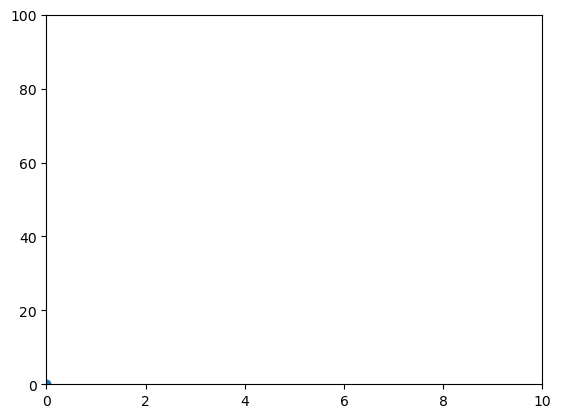

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

x = []
y = []

fig, ax = plt.subplots()
line, = ax.plot([], [], 'o-')

ax.set_xlim(0, 10)
ax.set_ylim(0, 100)

def update(frame):
    x.append(frame)
    y.append(frame**2)

    line.set_data(x, y)
    return line,

ani = FuncAnimation(
    fig,
    update,
    frames=range(11),
    interval=500,
    blit=True
)

plt.show()

In [2]:
import time

for i in range(10):
    value = i**2

    print(f"step={i}, value={value}")

    time.sleep(0.5)

step=0, value=0
step=1, value=1
step=2, value=4
step=3, value=9
step=4, value=16
step=5, value=25
step=6, value=36
step=7, value=49
step=8, value=64
step=9, value=81


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import os

# ============================================================
# GENERATE DATA USING A FOR LOOP
# ============================================================

nsteps = 20

history = []

for loop in range(nsteps):

    uplift_change = 2.0
    diffusion_change = 0.2 * loop

    z_A = uplift_change * loop
    z_B = uplift_change * loop - diffusion_change

    history.append([
        loop,
        uplift_change,
        diffusion_change,
        z_A,
        z_B
    ])

history = np.array(history)

# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.set_title("For Loop Execution Animation")
ax.set_xlabel("Loop Number")
ax.set_ylabel("Value")

ax.set_xlim(0, nsteps)
ax.set_ylim(0, np.max(history[:, 3]) + 5)

lineA, = ax.plot([], [], 'o-', label='z_A')
lineB, = ax.plot([], [], 's-', label='z_B')

ax.legend()

# Text box showing current values
text_box = ax.text(
    0.02,
    0.98,
    "",
    transform=ax.transAxes,
    verticalalignment="top",
    family="monospace",
    fontsize=10
)

# ============================================================
# INITIALIZATION FUNCTION
# ============================================================

def init():

    lineA.set_data([], [])
    lineB.set_data([], [])

    text_box.set_text("")

    return lineA, lineB, text_box

# ============================================================
# UPDATE FUNCTION
# ============================================================

def update(frame):

    x = history[:frame + 1, 0]

    z_A = history[:frame + 1, 3]
    z_B = history[:frame + 1, 4]

    lineA.set_data(x, z_A)
    lineB.set_data(x, z_B)

    current = history[frame]

    text_box.set_text(
        f"Loop = {int(current[0])}\n"
        f"Uplift = {current[1]:.2f}\n"
        f"Diffusion = {current[2]:.2f}\n"
        f"z_A = {current[3]:.2f}\n"
        f"z_B = {current[4]:.2f}"
    )

    return lineA, lineB, text_box

# ============================================================
# CREATE ANIMATION
# ============================================================

ani = FuncAnimation(
    fig,
    update,
    frames=nsteps,
    init_func=init,
    interval=500,
    blit=True
)

# ============================================================
# SAVE GIF IN NOTEBOOK DIRECTORY
# ============================================================

gif_file = "for_loop_demo.gif"

ani.save(
    gif_file,
    writer=PillowWriter(fps=2)
)

plt.close()

# ============================================================
# PRINT LOCATION
# ============================================================

print("GIF saved successfully!")
print("Location:")
print(os.path.abspath(gif_file))

GIF saved successfully!
Location:
/Users/biraj/Library/CloudStorage/Dropbox/readthedoc_biraj/geodynamics_surface_processes_notes/docs/source/_script/for_loop_demo.gif
